# pyEDITH Tutorial: ExoEarth Spectroscopy Case Study


Curator: [Aarynn Carter](https://www.stsci.edu/stsci-research/research-directory/aarynn-carter) (STScI)

This notebook walks through assessing the feasibility of distinguishing between different Earth-like spectra for a given Habitable Worlds Observatory (HWO) Early Achitecture Design (EAD) concept.

Start by importing the necessary packages, set the verbosity to pyEDITH to "info" for full information, and set the default style for HWO plots.

In [1]:
import os
import glob
import copy
import itertools
import requests
import io
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import minimize, NonlinearConstraint
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy import units as u
from synphot import SourceSpectrum, BlackBodyNorm1D
from pyEDITH import Filter, set_verbosity, parse_input
from pyEDITH import AstrophysicalScene, Observatory, Observation
from pyEDITH import calculate_exposure_time_or_snr
import hwostyle

# pyEDITH verbosity
set_verbosity(level="warning")

# Plot styling
hwostyle.use("light")
colors = hwostyle.palette

## 1: Initial Setup

We need to provide a quantitative metric for how to distinguish between any two spectra. Let us assume a 5$\sigma$ detection threshold, which corresponds to a $\chi^2$ value of 25 for Gaussian uncertainties.

We will also define the spectral channels of interest for the calculation, covering 0.4-1.8 $\mu$m. In pyEDITH these are defined as `Filter` objects, each with its own wavelength bounds and spectral resolution, which are later passed to the calculation via the `filter_list` parameter.

Note that if you need to conduct a more complex test such as comparing multiple models simultaneously, you may need to adopt a different metric.

In [2]:
SIGMA_TARGET = 5.0
CHI2_TARGET = SIGMA_TARGET ** 2

# Define the spectral channels as pyEDITH Filter objects
FILTERS = [
    Filter("VIS", low=0.4, high=0.85, resolution=140, type="IFS"),
    Filter("Bridge", low=0.85, high=1.1, resolution=140, type="IFS"),
    Filter("NIR", low=1.1, high=1.8, resolution=70, type="IFS"),
]

channel_names = [f.name for f in FILTERS]
n_channels = len(FILTERS)

Next, we need to provide all of the spectra we would like to compare, and extract the relevant information from them to provide to future calculations. Let's define a dictionary to do this, using the keys as the more readable names, and the values as the paths to the files.

In [3]:
# Assemble spectra
def load_spectrum(url):
    response = requests.get(url)
    print(response.status_code, url)   # debug line — remove later
    response.raise_for_status()        # raises a clear HTTPError if something's wrong
    return np.loadtxt(io.StringIO(response.text))

BASE_URL = "https://raw.githubusercontent.com/spacetelescope/hwo-tools/main/coron_model/planets/"

EARTH_SPECTRA_FILES = {
    "Archean Earth": BASE_URL + "ArcheanEarth_geo_albedo.txt",
    "Hazy Archean Earth": BASE_URL + "Hazy_ArcheanEarth_geo_albedo.txt",
    "Modern Earth": BASE_URL + "Earth_geo_albedo.txt",
    "Modern Earth 2": BASE_URL + "Earth2_geo_albedo.txt",
    "Proterozoic Earth (Low O2)": BASE_URL + "proterozoic_low_o2_geo_albedo.txt",
    "Proterozoic Earth (High O2)": BASE_URL + "proterozoic_hi_o2_geo_albedo.txt",
}

# Create a dictionary to store the extracted model spectra
models = {}
for label, path in EARTH_SPECTRA_FILES.items():
    arr = load_spectrum(path)
    wl = np.asarray(arr[:, 0], dtype=float)
    albedo = np.asarray(arr[:, 1], dtype=float)
    order = np.argsort(wl)
    models[label] = {
        "path": path,
        "wavelength_um": wl[order],
        "albedo": albedo[order],
    }

# And also extra the names from the dictionary keys
model_names = sorted(models.keys())
if len(model_names) < 2:
    raise ValueError("Need at least two Earth models for pairwise comparison.")

200 https://raw.githubusercontent.com/spacetelescope/hwo-tools/main/coron_model/planets/ArcheanEarth_geo_albedo.txt
200 https://raw.githubusercontent.com/spacetelescope/hwo-tools/main/coron_model/planets/Hazy_ArcheanEarth_geo_albedo.txt
200 https://raw.githubusercontent.com/spacetelescope/hwo-tools/main/coron_model/planets/Earth_geo_albedo.txt
200 https://raw.githubusercontent.com/spacetelescope/hwo-tools/main/coron_model/planets/Earth2_geo_albedo.txt
200 https://raw.githubusercontent.com/spacetelescope/hwo-tools/main/coron_model/planets/proterozoic_low_o2_geo_albedo.txt
200 https://raw.githubusercontent.com/spacetelescope/hwo-tools/main/coron_model/planets/proterozoic_hi_o2_geo_albedo.txt


Let's take a pause here and plot all of our spectra to see that things are working correctly.

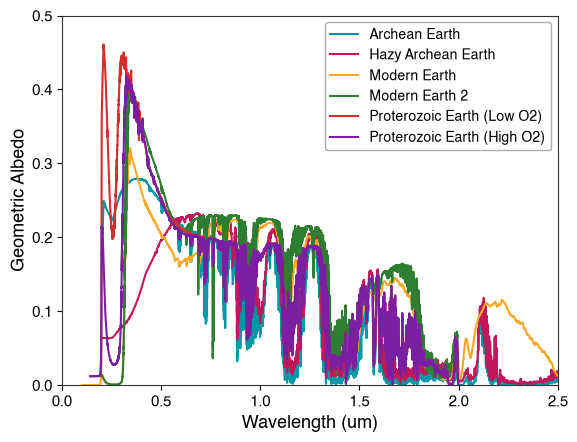

In [4]:
for name, spectrum in models.items():
    plt.plot(spectrum["wavelength_um"], spectrum["albedo"], label=name)
plt.xlabel("Wavelength (um)")
plt.ylabel("Geometric Albedo")
plt.xlim([0, 2.5])
plt.ylim([0, 0.5])
plt.legend()
plt.show()

Looks good! Now lets prepare our calculations. Specifically, we need to define the parameters for the simulations, including system specific parameters, instrument setup, and the input wavelength grid.

.. important::
Note that the input wavelength grid is simply the grid on which we provide the input spectra (stellar flux, planet contrast, target SNR). The actual resolved wavelength grid of each observation is determined by the `Filter` objects we defined above. pyEDITH will automatically rebin things during the actual calculations for a given filter, we just need to make sure the input grid covers the wavelength range of every filter.


In [5]:
# Define the system parameters, let's use Earth at 10 parsecs.
ap = 1 * u.au  # Semi-major axis of planet
rp = 1 * u.earthRad  # Radius of planet
phase_angle = np.pi/2

# And parameters for star
ra = 236.00757736823
dec = 2.51516683165
dist = 10 * u.pc  # Distance to the system
Tstar = 5800 * u.K
Rsol = 1.0 * u.Rsun

# And noise parameters
CRb_multiplier = 2.0 # Background multiplier
nzodis = 1.0 # Number of zodis

# Define the input wavelength grid on which all input spectra are provided.
# It must fully cover the wavelength range of every filter.
wl_input = np.linspace(0.2, 1.9, 1000)

# Define helper functions for stellar spectrum
def compute_blackbody_photon_flux(temp, wavelengths):
    """Generate photon flux density (photon/s/cm^2/um) for a blackbody."""
    bb = SourceSpectrum(BlackBodyNorm1D, temperature=temp)
    flux_photlam = bb(wavelengths)
    return flux_photlam

# Calculate the observed Fstar at 10 pc
wl_input_u = wl_input * u.um
Fstar = compute_blackbody_photon_flux(Tstar, wl_input_u)
Fstar = Fstar.to(u.photon / (u.s * u.cm**2 * u.nm))  # Convert to pyEDITH units
Fstar_obs_10pc = Fstar * (1000*u.pc / dist)**2  # Scale from 1 kpc (synphot default) to 10 pc

# Define the base parameters for the simulations. The spectral channels are
# specified through the filter_list parameter, and pyEDITH will rebin all
# input spectra onto each filter's resolved wavelength grid.
base_params = {
    # --- Observation setup ---
    "observing_mode": "IFS",
    "wavelength": wl_input,                     # input grid; rebinned per filter
    "filter_list": FILTERS,                     # spectral channels
    "snr": np.ones_like(wl_input),              # placeholder
    "CRb_multiplier": CRb_multiplier,

    # --- Astrophysical scene: star ---
    "distance": dist.value,                     # pc
    "stellar_radius": Rsol.value,               # solar radii
    "Fstar_10pc": Fstar_obs_10pc.value,         # photon/s/cm^2/nm
    "ra": ra,                                   # deg
    "dec": dec,                                 # deg

    # --- Astrophysical scene: planet ---
    "Fp/Fs": 1e-10 * np.ones_like(wl_input),    # placeholder
    "separation": ap.value / dist.value,        # arcsec

    # --- Astrophysical scene: zodi ---
    "nzodis": nzodis,

    # --- Observatory / instrument ---
    "observatory_preset": "EAC1",
    "psf_trunc_ratio": 0.3,
    "IFS_eff": [1.0]*len(wl_input),
    "noisefloor_PPF": 30,
    "ez_PPF": [np.inf]*len(wl_input),
}

Now we have defined some base settings for the calculation, we can parse the filter list to confirm which filters are active for our input wavelength range, and extract the resolved wavelength grid of each channel.

In [6]:
# Parse the filter list to validate it against the input wavelength range.
parsed_filters = parse_input.parse_filters(base_params)
for f in parsed_filters:
    print(f)

# Each Filter carries its own resolved wavelength grid.
wl_ch = {f.name: np.asarray(f.wavelength.to_value(u.um), dtype=float) for f in parsed_filters}

Filter(name='VIS', type='IFS', range=0.400 um-0.850 um, center=0.625 um, R=140)
Filter(name='Bridge', type='IFS', range=0.850 um-1.100 um, center=0.975 um, R=140)
Filter(name='NIR', type='IFS', range=1.100 um-1.800 um, center=1.450 um, R=70)


The calculations we perform will be based on the contrast ratio of the planet to its host star, which is a function of the geometric albedo, the phase angle, the radius of the planet, and the semi-major axis of the orbit.

In [7]:
# Helper function for computing contrast_ratio
def contrast_ratio(geometric_albedo, phase_angle, planet_radius, separation):
    phase_function = (np.sin(phase_angle) + (np.pi - phase_angle) * np.cos(phase_angle)) / np.pi
    return geometric_albedo * phase_function * (planet_radius / separation).decompose().value ** 2

fpfs_input_all = {}  # Contrast ratio on the input grid
# Loop over each model, compute the contrast ratio and interpolate onto the input grid
for name, model in models.items():
    fpfs_native = contrast_ratio(model["albedo"], phase_angle, rp, ap)
    fpfs_input_all[name] = np.interp(wl_input, model["wavelength_um"], fpfs_native)

## 2: Running The SNR Calculations

We're now in a position to start conducting calculations. We'll start by defining a function that uses the base parameters and the contrast ratio to produce all the relevant setups for a pyEDITH calculation, and then returns a second function that can be used to calculate the SNR for a given input exposure time.

In [8]:
def make_snr_runner(base_params, fpfs_input):
    """
    Build pyEDITH's observation, scene, and observatory setups
    and return a function that can call the SNR calculation
    for a given exposure time.

    Parameters
    ----------
    base_params : dict
        Base parameters for the pyEDITH calculation, including system and instrument setup.
    fpfs_input : dict
        Contrast ratio for the planet to star, keyed by channel name.

    Returns
    -------
    run : function
        A function that takes a reference exposure time (in hours) and returns the SNR results for each channel.
    fpfs_resolved : dict
        The contrast ratio rebinned onto the resolved wavelength grid of each channel, keyed by channel name.
    """
    params = copy.deepcopy(base_params)
    params["Fp/Fs"] = np.asarray(fpfs_input, dtype=float)

    setups = []
    fpfs_resolved = {} #pyEDITH rebinned Fp/FS
    for f in parse_input.parse_filters(params):
        observation = Observation()
        observation.load_configuration(params, filter=f)
        observation.set_output_arrays()
        observation.validate_configuration()

        scene = AstrophysicalScene()
        scene.load_configuration(params)
        scene.calculate_zodi_exozodi(params)
        scene.regrid_spectra(observation)

        fpfs = scene.Fp_over_Fs
        fpfs_resolved[f.name] = np.asarray(getattr(fpfs, "value", fpfs), dtype=float)

        observatory = Observatory()
        observatory.create_observatory(parse_input.get_observatory_config(params))
        observatory.load_configuration(params, observation, scene)
        observatory.validate_configuration()

        setups.append((f, observation, scene, observatory))

    def run(t_ref_hr):
        results = {}
        for f, observation, scene, observatory in setups:
            observation.set_output_arrays()  # reset outputs between runs
            observation.obstime = t_ref_hr * u.hr
            calculate_exposure_time_or_snr(observation, scene, observatory,
                                           mode="signal_to_noise")
            results[f.name] = {"wavelength": observation.wavelength,
                               "snr": observation.fullsnr}
        return results

    return run, fpfs_resolved

Now we can produce a measure of the SNR for any model and filter, however, we cannot simply scale a single reference exposure time to get the SNR for an arbitrary exposure. As pyEDITH accounts for multiple noise sources, the scaling is not linear. For example, if the reference exposure time is high we will be dominated by photon noise, but if it is low then we will be dominated by read noise. Therefore, instead of scaling a single reference exposure, we will build a grid calculations for a range of exposure times and then interpolate between them to get an appropriate noise estimate for any trial exposure time.

Note this cell can take ~20 seconds to run with the default grid spacing.

In [9]:
# Create a grid of reference exposure times in log-log space, from 1 to 100 hr
t_noise_grid = np.logspace(np.log10(1.0), np.log10(100), 30)

# Determine the per-channel noise templates for each model at every grid time.
sigma_grid_ch = {}
fpfs_ch = {}
for name in model_names:
    runner, fpfs_ch[name] = make_snr_runner(base_params, fpfs_input_all[name])
    rows = {cn: [] for cn in channel_names}
    for t in t_noise_grid:
        results = runner(t)
        for cn in channel_names:
            snr = np.asarray(getattr(results[cn]["snr"], "value", results[cn]["snr"]), dtype=float)
            rows[cn].append(fpfs_ch[name][cn] / np.clip(snr, 1e-30, np.inf))
    sigma_grid_ch[name] = {cn: np.vstack(rows[cn]) for cn in channel_names}

# log times for interpolation routine
_log_t_grid = np.log(t_noise_grid)
# Set a noise floor to avoid logging zero or negative values
_SIGMA_FLOOR = 1e-30

# Define function to return an interpolation function/interpolator for a given noise grid
def _make_sigma_interp(sigma_grid_2d, kind="slinear"):
    """
    Returns a interpolation function that can determine a noise template for any given exposure time
    """
    # Operate in log space
    log_sigma = np.log(np.clip(sigma_grid_2d, _SIGMA_FLOOR, None))
    #Build interpolation function
    f = interp1d(_log_t_grid, log_sigma, kind=kind, axis=0,
                 bounds_error=False, fill_value="extrapolate")
    lo, hi = t_noise_grid[0], t_noise_grid[-1]
    return lambda t: np.exp(f(np.log(np.clip(t, lo, hi))))

# Create interpolator for each individual channel of every model
sigma_interp_ch = {}
for name in model_names:
    # Dict comprehension over channels
    sigma_interp_ch[name] = {
        cn: _make_sigma_interp(sigma_grid_ch[name][cn])
        for cn in channel_names
    }

[pyEDITH] WARNING [2026-09-09 15:36:16,510] `FstarV_10pc` not specified in parameters. Calculating internally...
[pyEDITH] WARNING [2026-09-09 15:36:16,552] Coronagraph 'eac1_aavc_2d' not found locally. Attempting to fetch from remote database...
[yippy] WARNING [2026-09-09 15:36:16,878] Unhandled header fields: {'TMULCHAR', 'TMULDET'}
[yippy] WARNING [2026-09-09 15:36:16,878] Using default unit for D: m. Could not extract unit from comment: "circumscribed diameter of the telescope in mete"
[yippy] WARNING [2026-09-09 15:36:16,879] Using default unit for D_INSC: m. Could not extract unit from comment: "inscribed diameter of the telescope in meters"
[pyEDITH] WARNING [2026-09-09 15:36:17,516] No nrolls in YIPs, setting nrolls = 1.
[pyEDITH] WARNING [2026-09-09 15:36:17,602] `FstarV_10pc` not specified in parameters. Calculating internally...
[pyEDITH] WARNING [2026-09-09 15:36:17,633] Coronagraph 'eac1_aavc_2d' not found locally. Attempting to fetch from remote database...
[yippy] WARNI

## 3: Optimizing The Exposure Time

Now we need to take our individual model estimates and compare them in a pairwise fashion to identify how well we can distinguish between any two models. As observations in different channels can have different exposure times, we need to optimize the exposure time in each channel simultaneously to find the minimum required exposure time to reach the desired $\chi^2$ threshold.

There are two pieces to this that we need to produce. First, a function that determines the $\chi^2$ value for a given model pair and exposure time, and second, a function that optimizes the exposure times across the different channels together to reach the desired $\chi^2$ threshold in the minimum amount of time.

For the first, it's simply a case of calculating the sum of the squared differences between the two models, divided by the noise for the model we're assuming to be true.

In [10]:
def chi2_multichannel(times_vector, fpfs_ch_a, fpfs_ch_b, sigma_interp_a, channel_names, t_min=0.01):
    """
    Compute chi2 for a comparison between two models on a channel by channel basis

    Parameters
    ----------

    times_vector : 1D array
        Exposure times for each channel (hours), ordered as channel_names
    fpfs_ch_a : dict
        Contrast ratios for model A in each channel, keyed by channel name
    fpfs_ch_b : dict
        Contrast ratios for model B in each channel, keyed by channel name
    sigma_interp_a : dict
        Noise interpolators for model A in each channel, keyed by channel name
    channel_names : list of str
        Names of the channels (filter names)
    t_min : float, optional
        Minimum exposure time to avoid division by zero (default is 0.01 hours)

    Returns
    -------
    chi2 : float
        Chi-squared value for the comparison between the two models
    """

    delta_all = []
    sigma_all = []
    for i, cn in enumerate(channel_names):
        # Calculate the delta contrast ratio
        delta_all.append(fpfs_ch_a[cn] - fpfs_ch_b[cn])
        # Determine noise for this exposure time using interpolator
        sigma_all.append(sigma_interp_a[cn](times_vector[i]))

    delta_all = np.concatenate(delta_all)
    sigma_all = np.concatenate(sigma_all)

    valid = np.isfinite(delta_all) & np.isfinite(sigma_all) & (sigma_all > 0)
    if not np.any(valid):
        return np.inf

    # Calculate chi2
    chi2 = np.sum((delta_all[valid] / sigma_all[valid]) ** 2)
    return float(chi2)

And for the second, we can use `scipy.optimize.minimize` to find the optimal exposure times for each channel that minimize the total exposure time while still reaching the desired $\chi^2$ threshold. To ensure we don't get caught in a local minimum, we'll repeat the optimization with multiple random starting points and keep the best result.

In [11]:
def required_times_for_pair_multichannel(fpfs_ch_a, fpfs_ch_b, sigma_interp_a,
                                         channel_names, chi2_target=CHI2_TARGET,
                                         t_min=0.01, t_max=100.0, n_starts=10):
    """
    Find optimal per channel exposure times to distinguish two models that also
    minimizes the total exposure time across all channels.

    Parameters
    ----------
    fpfs_ch_a : dict
        Contrast ratios for model A in each channel, keyed by channel name
    fpfs_ch_b : dict
        Contrast ratios for model B in each channel, keyed by channel name
    sigma_interp_a : dict
        Noise interpolators for model A in each channel, keyed by channel name
    channel_names : list of str
        Names of the channels (filter names)
    chi2_target : float, optional
        Required chi2 value to distinguish the models
    t_min : float, optional
        Minimum exposure time to avoid division by zero (default is 0.01 hours)
    t_max : float, optional
        Maximum exposure time to avoid unbounded optimization (default is 100 hours)
    n_starts : int, optional
        Number of random starting points to try for optimization (default is 10)

    Returns
    -------
    times_opt : 1D array
        Optimal exposure times for each channel (hours), ordered as channel_names
    chi2_final : float
        Final chi2 value for the optimized exposure times
    """

    n_channels = len(channel_names)

    # Define the objective function we are trying to minimize (sum of times)
    def objective(times):
        return np.sum(times)

    # Define our constraint function, i.e. the chi2 for a given set of exposure times.
    def constraint_chi2(times):
        return chi2_multichannel(times, fpfs_ch_a, fpfs_ch_b, sigma_interp_a, channel_names, t_min)

    # Set the bounds on the optimization
    bounds = [(t_min, t_max) for _ in range(n_channels)]

    # And set the constraint for our chi2 to be above the target
    constraint = NonlinearConstraint(constraint_chi2, chi2_target, np.inf)

    best_result = None
    best_total_time = np.inf
    # Conduct multiple optimizations to avoid local minima
    for attempt in range(n_starts):
        if attempt == 0:
            # First attempt is at geometric mean as time is in log space
            x0 = np.full(n_channels, np.sqrt(t_min * t_max))
        else:
            # And the others are random in log space
            x0 = np.exp(np.random.uniform(np.log(t_min), np.log(t_max), n_channels))

        # Run minimizer, choice of SLSQP is intentional here to enable constraint.
        result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraint,
                          options={'ftol': 1e-6, 'maxiter': 1000})

        # Check if the total time is better than the current one
        if result.success:
            total_time = np.sum(result.x)
            if total_time < best_total_time:
                best_total_time = total_time
                best_result = result

    #Return best result
    if best_result is not None and best_result.success:
        times_opt = np.maximum(best_result.x, t_min)
        chi2_final = constraint_chi2(times_opt)
        return times_opt, chi2_final
    else:
        return np.full(n_channels, np.inf), 0.0

Great! We're ready to run the optimization. We'll set up a loop over all possible pairs of models that we're investigating and run the optimization for each pair.

Notice that we account for the bi-directionality of the comparison. The ability to distinguish between two scenarios depends on which one is assumed to be true, so we need to run the optimization twice for each direction and store the results.


Notice also that we define a pruning function to remove any contributions from channels at the lower edge of the time grid that contribute very little to the overall $\chi^2$ value. These are likely unphysical, and an artifact of pyEDITH SNR constraints at very low exposure times.

In [12]:
# Helper function to prune channels that are stuck at the lower bound and are not needed
def prune_unused_channels(times_opt, fpfs_ch_a, fpfs_ch_b, sigma_interp_a,
                          channel_names, chi2_target, t_min):
    """Because the initial time grid starts at a non-zero value, need to make sure
    we set results at the lower end of the grid (which are typically set to NaN) to zero
    if they have very little impact on the chi2.
    """
    times = np.asarray(times_opt, dtype=float).copy()

    # Gather per channel chi2 contributions
    contrib = np.zeros(len(channel_names))
    for i, cn in enumerate(channel_names):
        delta = fpfs_ch_a[cn] - fpfs_ch_b[cn]
        sigma = sigma_interp_a[cn](times[i])
        valid = np.isfinite(delta) & np.isfinite(sigma) & (sigma > 0)
        contrib[i] = np.sum((delta[valid] / sigma[valid]) ** 2)

    total = contrib.sum()
    # Find channels close to the lower time bound of the grid
    pinned = [i for i in np.argsort(contrib) if times[i] <= t_min * 1.01]
    for i in pinned:
        # Check if removal of channel affects chi2
        # Scale by slightly <1 to account for optimizer tolerance.
        if total - contrib[i] >= chi2_target * 0.999:
            total -= contrib[i]
            times[i] = 0.0 # Force time to zero
    return times

In [13]:
# Need to define a minimum and maximum exposure time, let's just use the limits of the interpolation grid
t_min_per_channel = t_noise_grid[0]    # 1 hr
t_max_per_channel = t_noise_grid[-1]   # 100 hr
nstarts = 10   #Number of starting positions for the optimizer

# Create an empty matrix to store the required exposure times
n = len(model_names)
t_required_matrix = np.full((n, n), np.nan, dtype=float)

# Fill diagonals with zeros as you cannot distinguish a model from itself.
np.fill_diagonal(t_required_matrix, 0.0)

pair_rows = []
# Loop over all possible pairs of models
for a, b in itertools.combinations(model_names, 2):
    # Case 1: Model A is true, distinguish from B (noise from A's interpolators)
    times_a_truth, chi2_a = required_times_for_pair_multichannel(
        fpfs_ch_a=fpfs_ch[a],
        fpfs_ch_b=fpfs_ch[b],
        sigma_interp_a=sigma_interp_ch[a],
        channel_names=channel_names,
        chi2_target=CHI2_TARGET,
        t_min=t_min_per_channel,
        t_max=t_max_per_channel,
        n_starts=nstarts
    )
    # Conduct pruning of low chi2 contributors
    times_a_truth = prune_unused_channels(times_a_truth, fpfs_ch[a], fpfs_ch[b],
                                      sigma_interp_ch[a], channel_names,
                                      CHI2_TARGET, t_min_per_channel)


    # Case 2: Model B is true, distinguish from A (noise from B's interpolators)
    times_b_truth, chi2_b = required_times_for_pair_multichannel(
        fpfs_ch_a=fpfs_ch[b],
        fpfs_ch_b=fpfs_ch[a],
        sigma_interp_a=sigma_interp_ch[b],
        channel_names=channel_names,
        chi2_target=CHI2_TARGET,
        t_min=t_min_per_channel,
        t_max=t_max_per_channel,
        n_starts=nstarts
    )
    # Conduct pruning of low chi2 contributors
    times_b_truth = prune_unused_channels(times_b_truth, fpfs_ch[b], fpfs_ch[a],
                                      sigma_interp_ch[b], channel_names,
                                      CHI2_TARGET, t_min_per_channel)

    # Store total times in matrix
    ia = model_names.index(a)
    ib = model_names.index(b)
    t_required_matrix[ia, ib] = np.sum(times_a_truth)
    t_required_matrix[ib, ia] = np.sum(times_b_truth)

    # Store per-channel breakdown
    pair_rows.append({
        "model_a": a,
        "model_b": b,
        "t_required_a_truth": np.sum(times_a_truth),
        "t_required_b_truth": np.sum(times_b_truth),
        "max_required_hours": max(np.sum(times_a_truth), np.sum(times_b_truth)),
        "chi2_a_truth": chi2_a,
        "chi2_b_truth": chi2_b,
        # Per-channel times for A truth
        **{f"t_{channel_names[ch]}_a_truth": times_a_truth[ch] for ch in range(n_channels)},
        # Per-channel times for B truth
        **{f"t_{channel_names[ch]}_b_truth": times_b_truth[ch] for ch in range(n_channels)},
    })

# Convert to a dataframe to make the visualisation a little easier.
t_required_matrix_df = pd.DataFrame(t_required_matrix, index=model_names, columns=model_names)
ranked_pairs = pd.DataFrame(pair_rows).sort_values("max_required_hours", ascending=True).reset_index(drop=True)

/Users/aacarter/miniconda3/envs/hwo/lib/python3.14/site-packages/scipy/optimize/_numdiff.py:710: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


As you can see, the optimization itself is quite fast compared to the generation of the noise templates. The results are now stored in a dataframe, and we can display the required total exposure times for each model pair as follows:

In [14]:
print("Directional matrix: rows are the assumed true model; columns are the competing model.")
display(t_required_matrix_df.round(2))

Directional matrix: rows are the assumed true model; columns are the competing model.


,Archean Earth,Hazy Archean Earth,Modern Earth,Modern Earth 2,Proterozoic Earth (High O2),Proterozoic Earth (Low O2)
Archean Earth,0.00,8.80,14.70,22.93,73.44,76.57
Hazy Archean Earth,8.25,0.00,9.37,5.24,6.21,6.22
Modern Earth,14.31,9.51,0.00,8.05,12.17,11.22
Modern Earth 2,23.67,5.68,8.39,0.00,59.19,63.82
Proterozoic Earth (High O2),75.76,6.73,12.61,58.41,0.00,inf
Proterozoic Earth (Low O2),79.12,6.74,11.63,63.07,inf,0.00


## 4: Visualizing the Results

The table output is useful, but it would be nice to visualize things a little more clearly, and also to see the per-channel breakdown of the required exposure times so we know which mode is the most important.

Let's make a heatmap figure instead:

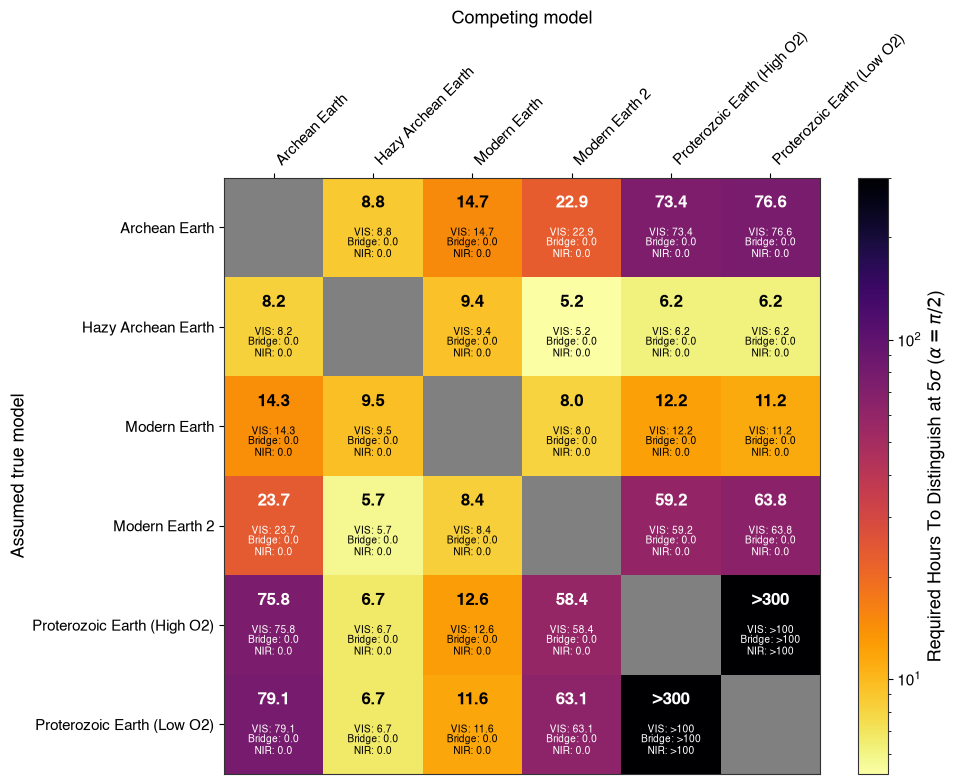

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap data
data = t_required_matrix_df.values.astype(float)

# Determine max finite value of required times for scaling of the colorbar
finite_mask = np.isfinite(data)
theoretical_max = n_channels * t_max_per_channel # i.e. 3 channels x 100 hrs = 300 hr max
inf_display_value = theoretical_max  # Place inf cells at theoretical max for coloring
data_display = np.copy(data)
data_display[~finite_mask] = inf_display_value

# Create colormap
cmap = plt.cm.inferno_r.copy()
cmap.set_bad("grey")
im = ax.imshow(data_display, origin="upper", norm=LogNorm(), cmap=cmap)

# Formatting
ax.set_xticks(np.arange(len(t_required_matrix_df.columns)))
ax.set_yticks(np.arange(len(t_required_matrix_df.index)))
ax.set_xticklabels(t_required_matrix_df.columns, rotation=45, ha="left")
ax.set_yticklabels(t_required_matrix_df.index)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax.set_xlabel("Competing model")
ax.set_ylabel("Assumed true model")
ax.grid(False)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f"Required Hours To Distinguish at {int(SIGMA_TARGET)}$\\sigma$ ($\\alpha=\\pi / 2$)")

# Build per-channel times lookup from ranked_pairs
model_names_list = list(t_required_matrix_df.index)

# For each cell, extract per-channel times
per_channel_times = {}
for idx, row in ranked_pairs.iterrows():
    a, b = row["model_a"], row["model_b"]
    ia, ib = model_names_list.index(a), model_names_list.index(b)
    # A as model truth
    per_channel_times[(ia, ib)] = [row[f"t_{channel_names[ch]}_a_truth"] for ch in range(n_channels)]
    # B as model truth
    per_channel_times[(ib, ia)] = [row[f"t_{channel_names[ch]}_b_truth"] for ch in range(n_channels)]

# Small function to format per channel times
def fmt_time(t, t_max=t_noise_grid[-1]):
    return f">{t_max:.0f}" if (not np.isfinite(t) or t >= t_max) else f"{t:.1f}"

# Annotate cells with required times.
for i in range(t_required_matrix_df.shape[0]):
    for j in range(t_required_matrix_df.shape[1]):
        val = t_required_matrix_df.values[i, j]
        
        if i == j:
            # Diagonals are self comparisons - skip
            txt_total = ""
            txt_channel = ""
        elif not np.isfinite(val):
            # If no valid exposure time, assume it's above the theoretical maximum
            txt_total = f">{theoretical_max:.0f}"
            txt_channel = "\n".join(f"{name}: {fmt_time(t)}" for name, t in zip(channel_names, per_channel_times[(i, j)]))
        else:
            # Time is just the total required time
            txt_total = f"{val:.1f}"
            txt_channel = "\n".join([f"{name}: {t:.1f}" for name, t in zip(channel_names, per_channel_times[(i, j)])])

        # Determine text color based on cell brightness
        if np.isfinite(val) and val > 0:
            rgba = im.cmap(im.norm(val))
            brightness = 0.2126*rgba[0] + 0.7152*rgba[1] + 0.0722*rgba[2]
            text_color = "black" if brightness > 0.5 else "white"
        else:
            # For inf cells, use the color at inf_display_value
            rgba = im.cmap(im.norm(inf_display_value))
            brightness = 0.2126*rgba[0] + 0.7152*rgba[1] + 0.0722*rgba[2]
            text_color = "black" if brightness > 0.5 else "white"
        
        # Add text for total and per channel times
        ax.text(j, i - 0.25, txt_total, ha="center", va="center", 
                fontsize=12, fontweight="bold", color=text_color)
        if txt_channel:
            ax.text(j, i + 0.15, txt_channel, ha="center", va="center", 
                    fontsize=7, color=text_color, linespacing=1.2)

plt.tight_layout()
plt.show()


Nice! It looks like we can constrain between most of the models in ~5-15 hours of exposure time. However, there are certainly some comparisons that are more challenging. We can also see that every comparison strongly prefers a single observation in the VIS channel, with the Bridge and NIR channels being disfavoured for this simple model comparison.

Let's finish by plotting the spectra and noise templates some of the comparisons to see what's going on.

The easiest model pair to distinguish is Hazy Archean Earth vs Modern Earth 2, which takes ~5 hours in the VIS channel to distinguish between. We can make another figure from the simulation results to see what's happening:

In [16]:
def plot_spectra_comparison(model_a, model_b):
    '''
    Plot the spectra comparison between two models with their respective noise templates.
    '''

    # Find the pair regardless of stored order
    pair_row = ranked_pairs[ranked_pairs[['model_a', 'model_b']].apply(frozenset, axis=1) == frozenset({model_a, model_b})]

    if pair_row.empty:
        print(f"Pair ({model_a}, {model_b}) not found in results")
    else:
        r = pair_row.iloc[0]
        # Because of the way the data is stored, we need to check if the provided order of model_a and model_b
        # is consistent with the stored order. If not, we can swap things round.
        a_is_stored_a = (r["model_a"] == model_a)
        suf_a = "a_truth" if a_is_stored_a else "b_truth"
        suf_b = "b_truth" if a_is_stored_a else "a_truth"

        # Use the per-channel noise interpolators to get the errors for each channel
        sigma_scaled_a = {cn: sigma_interp_ch[model_a][cn](r[f"t_{cn}_{suf_a}"]) for cn in channel_names}
        sigma_scaled_b = {cn: sigma_interp_ch[model_b][cn](r[f"t_{cn}_{suf_b}"]) for cn in channel_names}

        # Build the labels for the legend
        def label_fmt(t):
            return f">{t_noise_grid[-1]:.0f}" if (not np.isfinite(t) or t >= t_noise_grid[-1]) else f"{t:.1f}"
        label_a = ', '.join(f"{cn}={label_fmt(r[f't_{cn}_{suf_a}'])}" for cn in channel_names) + ' hr'
        label_b = ', '.join(f"{cn}={label_fmt(r[f't_{cn}_{suf_b}'])}" for cn in channel_names) + ' hr'

        # Create figure
        fig, ax = plt.subplots(figsize=(10, 6))

        # Track whether we've already added the "unused" legend entry
        unused_labeled = False

        # Plot each channel separately, only labelling the first to avoid duplicate legend entries
        for i, cn in enumerate(channel_names):
            wl = wl_ch[cn]

            # Plot model A with errors
            ax.plot(wl, fpfs_ch[model_a][cn], 'o-', linewidth=2.5, markersize=5,
                    label=f'{model_a} ({label_a})' if i == 0 else None, color='C0', zorder=3)
            ax.errorbar(wl, fpfs_ch[model_a][cn], yerr=sigma_scaled_a[cn],
                        fmt='none', ecolor='C0', alpha=0.5, capsize=3, linewidth=1.5, zorder=2)

            # Plot model B with errors
            ax.plot(wl, fpfs_ch[model_b][cn], 'o-', linewidth=2.5, markersize=5,
                    label=f'{model_b} ({label_b})' if i == 0 else None, color='C1', zorder=3)
            ax.errorbar(wl, fpfs_ch[model_b][cn], yerr=sigma_scaled_b[cn],
                        fmt='none', ecolor='C1', alpha=0.5, capsize=3, linewidth=1.5, zorder=2)

            # Shade this channel's wavelength range in gray if time is 0 hours
            t_a = r[f"t_{cn}_{suf_a}"]
            t_b = r[f"t_{cn}_{suf_b}"]
            if (np.isfinite(t_a) and t_a <= 0) or (np.isfinite(t_b) and t_b <= 0):
                ax.axvspan(
                    wl.min(), wl.max(),
                    color='grey', alpha=0.3, zorder=0,
                    label='Unused Spectral Channel (0.0 hr)' if not unused_labeled else None
                )
                unused_labeled = True

        # Formatting
        ax.set_xlabel("Wavelength (µm)", fontsize=14)
        ax.set_ylabel(f"Contrast Ratio ($\\alpha={phase_angle/np.pi:.2f}\\pi$)", fontsize=14)
        ax.set_xlim([0.35, 1.85])
        ax.set_ylim([0, 5e-10])
        ax.set_title(f"Spectral Comparison: {model_a} vs {model_b}", fontsize=12)
        ax.tick_params(which='both', direction='in', top=True, right=True)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10, loc='best')

        plt.tight_layout()
        plt.show()

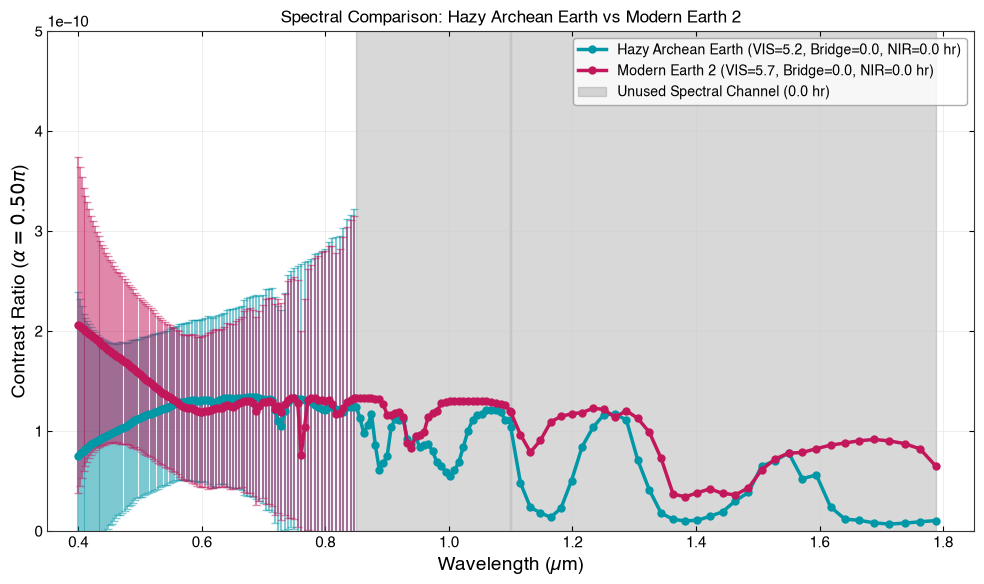

In [17]:
# Choose the models we'd like to compare and run the plotting function
model_a = "Hazy Archean Earth"
model_b = "Modern Earth 2"
plot_spectra_comparison(model_a, model_b)

For this comparison we can see that the VIS channel was deemed the most important likely due to the large divergence in the models between 0.4 and 0.6 microns, in combination with the resolution available at the VIS wavelengths. While there are divergences in the Bridge and NIR channels, the resolution and SNR were likely not sufficient to make them as important.

We can also see that the required observing time is a little longer if we assume the Modern Earth 2 model as the truth. This may seem counterintuitive, but likely results from the brighter model having a greater photon noise contribution, which makes it harder to distinguish - the noise from a brighter model can more easily mimic a fainter model than the noise from a fainter model can mimic a brighter one.

Let's look at one more example between the two Proterozoic Earth models, which indicate that an exposure time greater than 100 hours for any channel would be needed to distinguish between them.

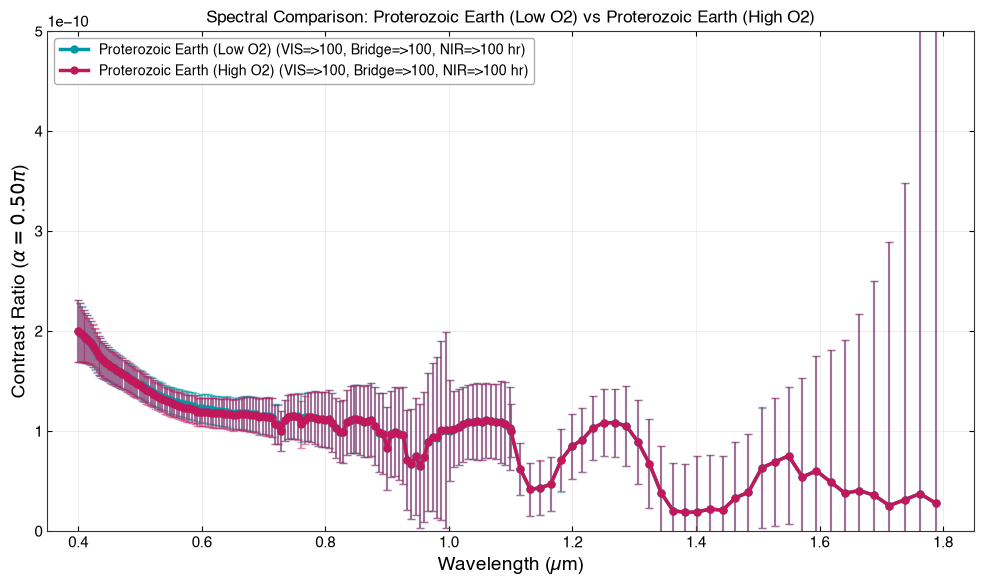

In [18]:
model_a = "Proterozoic Earth (Low O2)"
model_b = "Proterozoic Earth (High O2)"
plot_spectra_comparison(model_a, model_b)

Here we can see that the two models are extremely similar, with only small divergences in the VIS channel. Even with the long observation, we cannot reach sufficient SNR across the three channels to distinguish between them. Nevertheless, if needed, we could calculate the require time to distinguish between the two by extending the noise template grid to longer exposure times.

This marks the end of the notebook, congratulations on making it to the end! Hopefully you can see how the tools we've built can be used to distinguish between different atmospheric scenarios. More complex investigations could be conducted that build on this framework and explore more complex features such as atmospheric abundances and processes, across a wider range of planetary and stellar parameters, for a wider range of models.